In [1]:
# PROJE ÖZETİ — Fraud Detection & Cost-Based Threshold Optimization

## 1) Problem Tanımı ve Amaç

Bu projenin amacı, kredi kartı işlemlerinde **fraud tespiti** yapan bir model kurmak ve modelin kararını sadece **accuracy** üzerinden değil, **iş maliyetlerine** göre optimize etmektir.

Odak noktaları:

* **False Positive (FP):** Gereksiz kart/işlem bloklama → müşteri deneyimi ve operasyon maliyeti
* **False Negative (FN):** Fraud kaçırma → direkt finansal kayıp
* **Maliyet bazlı optimal threshold seçimi**
* **İş önceliklerine duyarlı karar mekanizması**

---

## 2) Veri Seti

Kullanılan veri: **Kaggle Credit Card Fraud** veri seti

* Toplam işlem: **284,807**
* Fraud işlem: **492** (**%0.17**)
* Aşırı sınıf dengesizliği nedeniyle **accuracy tek başına anlamlı değil**.

---

## 3) Veri Hazırlığı

* Train/test split: **%70 / %30**
* **Stratify** ile fraud oranı korunarak bölme
* Logistic Regression için **StandardScaler**
* `class_weight="balanced"` ile imbalance etkisini azaltma

---

## 4) Baseline Model: Logistic Regression

İlk gözlemler:

* Recall’ı artırma çabası precision’ı düşürüyor (klasik PR trade-off)
* Threshold arttıkça **precision artıyor**, **recall düşüyor**
* Accuracy “her koşulda” yüksek görünüp yanıltıcı olabiliyor

---

## 5) Threshold Analizi (Grid Search)

* Threshold aralığı: **0.05 – 0.95**
* Sonuç: **Optimal threshold çok yüksek** çıktı (**~0.95+**)

Yorum:

* Model, FP maliyetini artırmadan FN’i anlamlı şekilde düşüremiyor
* “FN’i azaltayım” derken FP artışı maliyeti telafi etmiyor → optimum yukarı kayıyor

---

## 6) Cost-Based Evaluation

Toplam maliyet:
**Total Cost = FP × FP_cost + FN × FN_cost**

Farklı maliyet senaryolarında test:

* FP maliyeti yükseldikçe optimum threshold **yukarı** kaydı
* Precision arttı, recall azaldı
* Threshold seçimi **iş önceliklerine duyarlı** olduğunu açıkça gösterdi

---

## 7) Grid Hassasiyeti (Fine Search)

Daha hassas arama: **0.90 – 0.999**

* Gerçek optimum: **0.967 – 0.999** bandında bulundu

Bu bölüm, projenin “**karar optimizasyonu**” tarafını güçlendiriyor.

---

## 8) Calibration Denemesi (Platt / Sigmoid)

Kalibrasyon sonrası gözlem:

* Threshold daha “makul” seviyeye geldi (**~0.90**)
* Precision arttı
* Recall ciddi düştü (**~%50 civarı**)
* FN maliyeti 2000 olsa bile threshold anlamlı şekilde aşağı kaymadı

Çıkarım:

* Logistic Regression’ın ayrım gücü sınırlı → threshold ayarıyla recall “kurtarılamıyor”

---

## Kritik Teknik Sonuç

**Threshold optimizasyonu modeli kurtaramaz.**
Modelin ayırma gücü yetersizse, karar eşiğini oynatmak **recall’u anlamlı artırmaz**.

Bu nedenle **non-linear ve daha güçlü modeller** denenmelidir.

---

## Sonraki Adımlar (Yeni Notebook Planı)

1. Veri yükleme + train/test split
2. **Random Forest** baseline
3. Temel metrikler + **PR-AUC**
4. **Cost-based threshold optimizasyonu**
5. Logistic Regression ile karşılaştırma
6. Gerekirse **Gradient Boosting** ekleme
7. Model karşılaştırma + cost sensitivity analysis + iş yorumu

---

## Projenin Güçlü Yanları

* Class imbalance farkındalığı
* Precision–Recall odağı
* Cost-based threshold selection
* Hassasiyet analizi (fine grid)
* Calibration denemesi
* Model comparison yaklaşımı

Bu çalışma, “model denedim bitti” değil; net biçimde bir **Decision Optimization** projesi.

---

Hazır olduğunda sadece şunu yaz: **“RF ile başlıyoruz”**
Ben de notebook akışını adım adım (kod blokları + kontrol noktalarıyla) kuralım.


In [30]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
      confusion_matrix, classification_report,
      precision_recall_curve, average_precision_score
)

In [2]:
df=pd.read_csv("creditcard.csv")
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [3]:
df.shape

(284807, 31)

In [4]:
df["Class"].value_counts()

Class
0    284315
1       492
Name: count, dtype: int64

In [5]:
df["Class"].value_counts(normalize=True)

Class
0    0.998273
1    0.001727
Name: proportion, dtype: float64

In [6]:
X= df.drop("Class", axis=1)
y=df["Class"]

X_train, X_test, y_train, y_test=train_test_split(
    X,y, test_size=0.2, stratify=y, random_state=42
)
X_train.shape, X_test.shape

((227845, 30), (56962, 30))

In [7]:
print("Train fraud oranı:")
print(y_train.value_counts(normalize=True))

print("\nTest fraud oranı:")
print(y_test.value_counts(normalize=True))

Train fraud oranı:
Class
0    0.998271
1    0.001729
Name: proportion, dtype: float64

Test fraud oranı:
Class
0    0.99828
1    0.00172
Name: proportion, dtype: float64


In [8]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

lr_pipe= Pipeline(steps=[
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(max_iter=5000, class_weight="balanced"))
])

lr_pipe.fit(X_train, y_train)

y_pred = lr_pipe.predict(X_test)
print(classification_report(y_test, y_pred, digits=4))

              precision    recall  f1-score   support

           0     0.9999    0.9756    0.9876     56864
           1     0.0610    0.9184    0.1144        98

    accuracy                         0.9755     56962
   macro avg     0.5304    0.9470    0.5510     56962
weighted avg     0.9982    0.9755    0.9861     56962



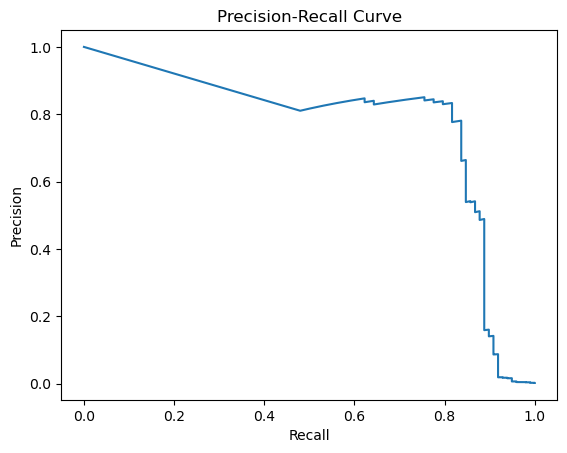

In [9]:
y_scores = lr_pipe.predict_proba(X_test)[:, 1]

precision, recall, thresholds = precision_recall_curve(y_test, y_scores)

import matplotlib.pyplot as plt

plt.figure()
plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.show()


In [10]:
import numpy as np

for t in [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7]:
    y_pred_t = (y_scores >= t).astype(int)
    print(f"\nThreshold: {t}")
    print(classification_report(y_test, y_pred_t, digits=4))


Threshold: 0.1
              precision    recall  f1-score   support

           0     0.9999    0.8010    0.8895     56864
           1     0.0082    0.9490    0.0162        98

    accuracy                         0.8013     56962
   macro avg     0.5040    0.8750    0.4528     56962
weighted avg     0.9982    0.8013    0.8880     56962


Threshold: 0.2
              precision    recall  f1-score   support

           0     0.9999    0.9030    0.9490     56864
           1     0.0164    0.9388    0.0323        98

    accuracy                         0.9031     56962
   macro avg     0.5081    0.9209    0.4906     56962
weighted avg     0.9982    0.9031    0.9474     56962


Threshold: 0.3
              precision    recall  f1-score   support

           0     0.9999    0.9437    0.9710     56864
           1     0.0273    0.9184    0.0531        98

    accuracy                         0.9437     56962
   macro avg     0.5136    0.9310    0.5120     56962
weighted avg     0.9982   

In [11]:
import numpy as np
from sklearn.metrics import confusion_matrix

cost_fp = 10
cost_fn = 200

for t in [0.3, 0.44, 0.5, 0.6, 0.7]:
    y_pred_t = (y_scores >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred_t).ravel()

    total_cost = fp*cost_fp + fn + cost_fn
    print(f"\nThreshold: {t}")
    print(f"FP: {fp}), FN: {fn}")
    print(f"Total Cost: {total_cost}")


Threshold: 0.3
FP: 3201), FN: 8
Total Cost: 32218

Threshold: 0.44
FP: 1744), FN: 8
Total Cost: 17648

Threshold: 0.5
FP: 1386), FN: 8
Total Cost: 14068

Threshold: 0.6
FP: 937), FN: 9
Total Cost: 9579

Threshold: 0.7
FP: 645), FN: 9
Total Cost: 6659


In [12]:
import numpy as np
from sklearn.metrics import confusion_matrix

cost_fp = 10
cost_fn = 500

for t in [0.3, 0.44, 0.5, 0.6, 0.7]:
    y_pred_t = (y_scores >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred_t).ravel()

    total_cost = fp*cost_fp + fn + cost_fn
    print(f"\nThreshold: {t}")
    print(f"FP: {fp}), FN: {fn}")
    print(f"Total Cost: {total_cost}")


Threshold: 0.3
FP: 3201), FN: 8
Total Cost: 32518

Threshold: 0.44
FP: 1744), FN: 8
Total Cost: 17948

Threshold: 0.5
FP: 1386), FN: 8
Total Cost: 14368

Threshold: 0.6
FP: 937), FN: 9
Total Cost: 9879

Threshold: 0.7
FP: 645), FN: 9
Total Cost: 6959


In [13]:
test = X_test.copy()
test["y_true"]= y_test.values
test["score"]= y_scores

In [14]:
test["amount_seg"] = pd.qcut(test["Amount"], q=3, labels=["low","mid","high"])
test["amount_seg"].value_counts()

amount_seg
low     19582
high    18981
mid     18399
Name: count, dtype: int64

In [15]:
test.groupby("amount_seg")["Amount"].agg(["min","max","mean"])

/var/folders/hk/nvq3n50s3fv2kw083bwlpp580000gn/T/ipykernel_4458/83920194.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  test.groupby("amount_seg")["Amount"].agg(["min","max","mean"])


,min,max,mean
amount_seg,,,
low,0.0,9.99,3.714206
mid,10.0,49.99,25.165221
high,50.0,12910.93,238.992412


In [16]:
import numpy as np
from sklearn.metrics import confusion_matrix

FP_COST = 10
FN_COST = 500

threshold_grid = np.linspace(0.05,0.95,19)

results = []

for seg in ["low","mid","high"]:
    seg_df=test[test["amount_seg"] == seg].copy()
    y_true=seg_df["y_true"].values
    scores=seg_df["score"].values
    best=None

    for t in threshold_grid:
        y_pred=(scores >= t).astype(int)
        tn,fp,fn,tp = confusion_matrix(y_true, y_pred, labels=[0,1]).ravel()
        total_cost = fp*FP_COST + fn*FN_COST

        row = {
            "segment": seg, "threshold": float(t),
            "tp": int(tp), "fp": int(fp), "fn": int(fn), "tn":int(tn),
            "total_cost": float(total_cost)
        }
        results.append(row)

        if (best is None) or (total_cost< best["total_cost"]):
            best = row

    print(f"\nBest threshold for segment={seg}: {best['threshold']}")
    print(f"FP={best['fp']} FN={best['fn']} TotalCost={best['total_cost']}")



Best threshold for segment=low: 0.95
FP=54 FN=6 TotalCost=3540.0

Best threshold for segment=mid: 0.95
FP=18 FN=1 TotalCost=680.0

Best threshold for segment=high: 0.95
FP=64 FN=4 TotalCost=2640.0


In [17]:
test = X_test.copy()
test["y_true"]= y_test.values
test["score"]= y_scores 
test["amount_seg"] = pd.qcut(test["Amount"], q=3, labels=["low","mid","high"])

test["amount_seg"].value_counts()

amount_seg
low     19582
high    18981
mid     18399
Name: count, dtype: int64

In [18]:
import numpy as np
from sklearn.metrics import confusion_matrix

FP_COST = 10
threshold_grid = np.linspace(0.05,0.95,19)

results_amt_cost = []

for seg in ["low","mid","high"]:
    seg_df=test[test["amount_seg"] == seg].copy()
    y_true=seg_df["y_true"].values
    scores=seg_df["score"].values
    amounts = seg_df["Amount"].values
    
    best=None
    for t in threshold_grid:
        y_pred = (scores>= t).astype(int)
        tn = np.sum((y_true == 0)& (y_pred == 0))
        fp = np.sum((y_true == 0)& (y_pred == 1))
        fn = np.sum((y_true == 1)& (y_pred == 0))
        tp = np.sum((y_true == 1)& (y_pred == 1))

        fn_cost_sum = amounts[(y_true == 1) & (y_pred == 0)].sum()

        total_cost = fp*FP_COST + fn_cost_sum
        row = {
            "segment": seg, "threshold": float(t),
            "tp": int(tp), "fp": int(fp), "fn": int(fn), "tn": int(tn),
            "fn_cost_sum": float(fn_cost_sum),
            "total_cost": float(total_cost)
        }
        results_amt_cost.append(row)

        if (best is None) or (total_cost < best["total_cost"]):
            best = row

    print(f"\nBest threshold for segment={seg}: {best['threshold']}")
    print(f"FP={best['fp']}  FN={best['fn']}  FN_cost_sum={best['fn_cost_sum']:.2f}  TotalCost={best['total_cost']:.2f}")


Best threshold for segment=low: 0.95
FP=54  FN=6  FN_cost_sum=14.54  TotalCost=554.54

Best threshold for segment=mid: 0.95
FP=18  FN=1  FN_cost_sum=29.95  TotalCost=209.95

Best threshold for segment=high: 0.95
FP=64  FN=4  FN_cost_sum=1782.01  TotalCost=2422.01


In [19]:
import numpy as np
from sklearn.metrics import confusion_matrix

threshold_grid = np.linspace(0.05,0.95,19)

def evaluate_cost(fp_cost, fn_cost):
    best=None

    for t in threshold_grid:
        y_pred = (y_scores >= t).astype(int)
        tn,fp,fn,tp = confusion_matrix(y_test, y_pred).ravel()
        total_cost = fp * fp_cost + fn * fn_cost
        
        if (best is None) or (total_cost < best["total_cost"]):
            best = {
                "threshold": t,
                "fp": fp,
                "fn": fn,
                "total_cost": total_cost
            }
    return best
scenario_10 = evaluate_cost(fp_cost=10, fn_cost=500)
scenario_50 = evaluate_cost(fp_cost=50, fn_cost=500)

print("FP cost=10:", scenario_10)
print("FP cost=50:", scenario_50)


FP cost=10: {'threshold': np.float64(0.95), 'fp': np.int64(136), 'fn': np.int64(11), 'total_cost': np.int64(6860)}
FP cost=50: {'threshold': np.float64(0.95), 'fp': np.int64(136), 'fn': np.int64(11), 'total_cost': np.int64(12300)}


In [20]:
threshold_grid_hi = np.linspace(0.90, 0.999, 20)

def evaluate_cost_grid(fp_cost, fn_cost, grid):
    best = None
    for t in grid:
        y_pred = (y_scores >= t).astype(int)
        tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
        total_cost = fp * fp_cost + fn * fn_cost
        if (best is None) or (total_cost < best["total_cost"]):
            best = {"threshold": float(t), "fp": int(fp), "fn": int(fn), "total_cost": float(total_cost)}
    return best

scenario_10_hi = evaluate_cost_grid(fp_cost=10, fn_cost=500, grid=threshold_grid_hi)
scenario_50_hi = evaluate_cost_grid(fp_cost=50, fn_cost=500, grid=threshold_grid_hi)

print("FP cost=10 (0.90-0.999):", scenario_10_hi)
print("FP cost=50 (0.90-0.999):", scenario_50_hi)

FP cost=10 (0.90-0.999): {'threshold': 0.9677368421052632, 'fp': 98, 'fn': 11, 'total_cost': 6480.0}
FP cost=50 (0.90-0.999): {'threshold': 0.999, 'fp': 42, 'fn': 15, 'total_cost': 9600.0}


In [21]:
from sklearn.metrics import classification_report

def report_at_threshold(t):
    y_pred_t = (y_scores >= t).astype(int)
    print("Threshold:", t)
    print(classification_report(y_test, y_pred_t, digits=4))

report_at_threshold(0.9677368421052632)
report_at_threshold(0.999)

Threshold: 0.9677368421052632
              precision    recall  f1-score   support

           0     0.9998    0.9983    0.9990     56864
           1     0.4703    0.8878    0.6148        98

    accuracy                         0.9981     56962
   macro avg     0.7350    0.9430    0.8069     56962
weighted avg     0.9989    0.9981    0.9984     56962

Threshold: 0.999
              precision    recall  f1-score   support

           0     0.9997    0.9993    0.9995     56864
           1     0.6640    0.8469    0.7444        98

    accuracy                         0.9990     56962
   macro avg     0.8319    0.9231    0.8719     56962
weighted avg     0.9992    0.9990    0.9991     56962



In [23]:
from sklearn.calibration import CalibratedClassifierCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
base_lr = Pipeline(steps=[
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(max_iter=5000, class_weight="balanced"))
])
cal_lr_sigmoid = CalibratedClassifierCV(estimator=base_lr, method="sigmoid", cv=3)
cal_lr_sigmoid.fit(X_train, y_train)

y_scores_cal_sigmoid = cal_lr_sigmoid.predict_proba(X_test)[:,1]

In [28]:
import numpy as np
from sklearn.metrics import confusion_matrix

threshold_grid_hi = np.linspace(0.90, 0.90, 18)

def evaluate_cost_with_scores(scores, fp_cost, fn_cost, grid):
    best = None
    for t in grid:
        y_pred = (scores >= t).astype(int)
        tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
        total_cost = fp * fp_cost + fn * fn_cost
        if (best is None) or (total_cost < best["total_cost"]):
            best = {"threshold": float(t), "fp": int(fp), "fn": int(fn), "total_cost": float(total_cost)}
    return best

best_cal_fp10 = evaluate_cost_with_scores(y_scores_cal_sigmoid, fp_cost=10, fn_cost=2000, grid=threshold_grid_hi)
best_cal_fp50 = evaluate_cost_with_scores(y_scores_cal_sigmoid, fp_cost=50, fn_cost=2000, grid=threshold_grid_hi)

print("Wide grid calibrated FP=10:", best_cal_fp10)
print("Wide grid calibrated FP=50:", best_cal_fp50)

Wide grid calibrated FP=10: {'threshold': 0.9, 'fp': 11, 'fn': 49, 'total_cost': 98110.0}
Wide grid calibrated FP=50: {'threshold': 0.9, 'fp': 11, 'fn': 49, 'total_cost': 98550.0}


In [29]:
from sklearn.metrics import classification_report

def report_at_threshold(scores, t):
    y_pred_t = (scores >= t).astype(int)
    print("Threshold:", t)
    print(classification_report(y_test, y_pred_t, digits=4))

report_at_threshold(y_scores_cal_sigmoid, best_cal_fp10["threshold"])
report_at_threshold(y_scores_cal_sigmoid, best_cal_fp50["threshold"])

Threshold: 0.9
              precision    recall  f1-score   support

           0     0.9991    0.9998    0.9995     56864
           1     0.8167    0.5000    0.6203        98

    accuracy                         0.9989     56962
   macro avg     0.9079    0.7499    0.8099     56962
weighted avg     0.9988    0.9989    0.9988     56962

Threshold: 0.9
              precision    recall  f1-score   support

           0     0.9991    0.9998    0.9995     56864
           1     0.8167    0.5000    0.6203        98

    accuracy                         0.9989     56962
   macro avg     0.9079    0.7499    0.8099     56962
weighted avg     0.9988    0.9989    0.9988     56962

